In [ ]:
import pandas as pd

# 1. Excel dosyası
excel_dosya_adi = "Telco_customer_churn.xlsx"
df_excel = pd.read_excel(excel_dosya_adi)

# 2. Dosyayı doğrudan CSV formatına dönüştür
csv_dosya_adi = "Telco_customer_churn.csv"
df_excel.to_csv(csv_dosya_adi, index=False)

print(f"Başarılı! Dosyanız '{csv_dosya_adi}' adıyla CSV formatına dönüştürüldü.")

Başarılı! Dosyanız 'Telco_customer_churn.csv' adıyla CSV formatına dönüştürüldü.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Hazır olan CSV dosyasını doğrudan Pandas DataFrame olarak okuma işlemi
df = pd.read_csv("Telco_customer_churn.csv")

# Veri setinin boyutuna, ilk 5 satırına ve sütun tiplerine bakma işlemi
print("Veri Seti Boyutu:", df.shape)
print("\nİlk 5 Satır:")
print(df.head())
print("\nVeri Tipleri ve Genel Bilgi:")
print(df.info())

Veri Seti Boyutu: (7043, 33)

İlk 5 Satır:
   CustomerID  Count        Country       State         City  Zip Code  \
0  3668-QPYBK      1  United States  California  Los Angeles     90003   
1  9237-HQITU      1  United States  California  Los Angeles     90005   
2  9305-CDSKC      1  United States  California  Los Angeles     90006   
3  7892-POOKP      1  United States  California  Los Angeles     90010   
4  0280-XJGEX      1  United States  California  Los Angeles     90015   

                 Lat Long   Latitude   Longitude  Gender  ...        Contract  \
0  33.964131, -118.272783  33.964131 -118.272783    Male  ...  Month-to-month   
1   34.059281, -118.30742  34.059281 -118.307420  Female  ...  Month-to-month   
2  34.048013, -118.293953  34.048013 -118.293953  Female  ...  Month-to-month   
3  34.062125, -118.315709  34.062125 -118.315709  Female  ...  Month-to-month   
4  34.039224, -118.266293  34.039224 -118.266293    Male  ...  Month-to-month   

  Paperless Billing      

In [ ]:
# Uyarı veren zincirleme atama (chained assignment) yerine modern Pandas yazımı kullanımı
df['Total Charges'] = df['Total Charges'].replace(" ", np.nan)
df['Total Charges'] = pd.to_numeric(df['Total Charges'])

# inplace=True yerine doğrudan sütuna eşitleme yapma işlemi
df['Total Charges'] = df['Total Charges'].fillna(df['Total Charges'].median())

# Tahmin modelini yanıltacak ID, coğrafi koordinatlar ve Churn Reason gibi sütunları düşürme işlemi
drop_cols = ['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
             'Lat Long', 'Latitude', 'Longitude', 'Churn Label', 'Churn Score',
             'CLTV', 'Churn Reason']

df.drop(columns=drop_cols, inplace=True, errors='ignore')

print("Temizlik Sonrası Kalan Sütunlar:\n", df.columns.tolist())
print("\nKalan Eksik Değer Sayısı:\n", df.isnull().sum())

Temizlik Sonrası Kalan Sütunlar:
 ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value']

Kalan Eksik Değer Sayısı:
 Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn Value          0
dtype: int64


/tmp/ipykernel_1469/2761542253.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn Value', data=df, palette='Set2')


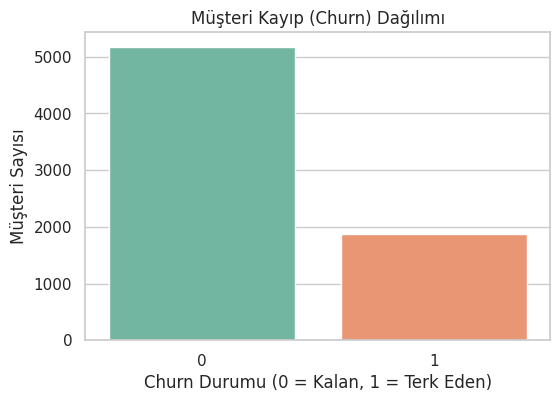

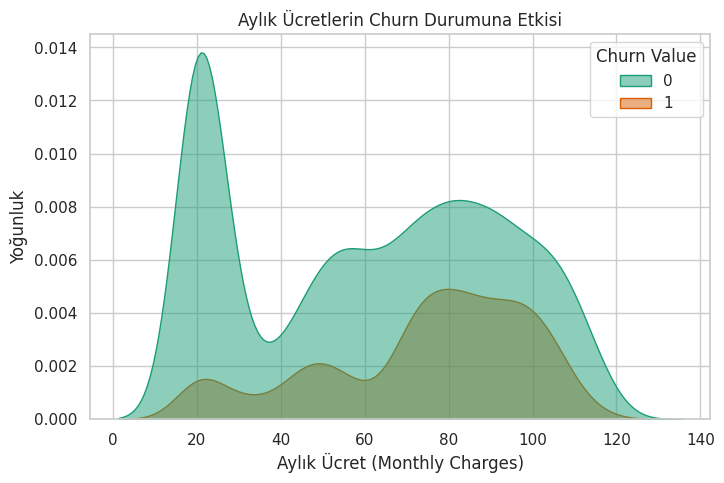

In [ ]:
# Seaborn estetik temasını aktif etme satırı
sns.set_theme(style="whitegrid")

# Görsel 1: Hedef Değişken (Churn Value) Dağılımı - Sınıf Dengesizliğini Göstermek İçin
plt.figure(figsize=(6,4))
sns.countplot(x='Churn Value', data=df, palette='Set2')
plt.title('Müşteri Kayıp (Churn) Dağılımı')
plt.xlabel('Churn Durumu (0 = Kalan, 1 = Terk Eden)')
plt.ylabel('Müşteri Sayısı')
plt.savefig('churn_dagilim.png', dpi=300, bbox_inches='tight')
plt.show()

# Görsel 2: Aylık Ücretlerin Churn Durumuna Göre Dağılım Yoğunluğu
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x='Monthly Charges', hue='Churn Value', fill=True, palette='Dark2', alpha=0.5)
plt.title('Aylık Ücretlerin Churn Durumuna Etkisi')
plt.xlabel('Aylık Ücret (Monthly Charges)')
plt.ylabel('Yoğunluk')
plt.savefig('monthly_charges_kde.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE

# Sütun isimlerini senin veri setine göre eşitleme işlemi
X = df.drop('Churn Value', axis=1)
y = df['Churn Value']

# Kategorik özellikleri One-Hot Encoding ile sayısallaştırma işlemi
X_encoded = pd.get_dummies(X, drop_first=True)

# Sayısal özellikleri 0-1 arasına ölçekleme (Normalizasyon)
scaler = MinMaxScaler()
numerical_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges']
X_encoded[numerical_cols] = scaler.fit_transform(X_encoded[numerical_cols])

# %70 Eğitim, %30 Test olarak veriyi bölme (Sınıf oranını stratify ile koruma işlemi)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=42, stratify=y)

# SMOTE Uygulaması (Sadece eğitim kümesine!)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("SMOTE Sonrası Eğitim Kümesi Boyutu:", X_train_res.shape)
print("Sınıf Dağılımı (Kalıcı [0] vs Kayıp [1]):", np.bincount(y_train_res))

SMOTE Sonrası Eğitim Kümesi Boyutu: (7244, 30)
Sınıf Dağılımı (Kalıcı [0] vs Kayıp [1]): [3622 3622]



=== 5.1 PERFORMANS TABLOSU ===
                Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
        Decision Tree  0.731661   0.495356 0.570410  0.530240 0.680745
Random Forest (Tuned)  0.776148   0.566465 0.668449  0.613246 0.829996
  Logistic Regression  0.757690   0.530061 0.770053  0.627907 0.847526


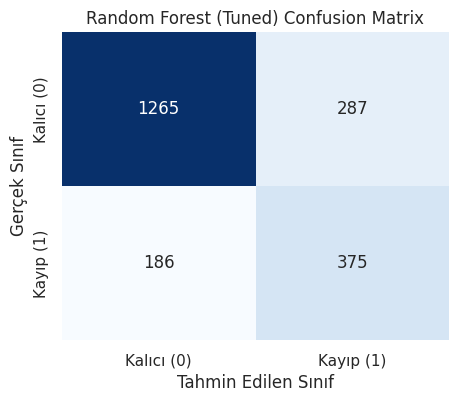

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# 1. Random Forest için Hızlı GridSearch Ayarı
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20]
}
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, scoring='f1', n_jobs=-1)
grid_search.fit(X_train_res, y_train_res)
best_rf = grid_search.best_estimator_

# 2. Modelleri Tanımlama ve Eğitme
trained_models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42).fit(X_train_res, y_train_res),
    "Random Forest (Tuned)": best_rf,
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000).fit(X_train_res, y_train_res)
}

# 3. Test Verisi Üzerinde Metriklerin Hesaplanması
results_list = []
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }
    results_list.append(metrics)

# Sonuçları Tablo Olarak Yazdıralım
df_results = pd.DataFrame(results_list)
print("\n=== HOCANIN İSTEDİĞİ BÖLÜM 5.1 PERFORMANS TABLOSU ===")
print(df_results.to_string(index=False))

# 4. En İyi Model İçin Confusion Matrix Çizimi ve Kaydedilmesi
cm = confusion_matrix(y_test, trained_models["Random Forest (Tuned)"].predict(X_test))
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Kalıcı (0)', 'Kayıp (1)'],
            yticklabels=['Kalıcı (0)', 'Kayıp (1)'])
plt.ylabel('Gerçek Sınıf')
plt.xlabel('Tahmin Edilen Sınıf')
plt.title('Random Forest (Tuned) Confusion Matrix')
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()